**Upload CSV File**

In [1]:
from google.colab import files
uploaded = files.upload()  # Upload clean_clinical_data.csv when prompted

Saving clean_clinical_data.csv to clean_clinical_data.csv


**Install & Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('clean_clinical_data.csv')
print(df.shape)
df.head()

(5008, 7)


,SUBJID,AGE,SEX,AE_TERM,SEVERITY,TEST,VALUE
0,8,56,F,Headache,Moderate,WBC,104.930968
1,10,40,F,Fever,Mild,Platelets,110.071642
2,11,28,F,Nausea,Severe,Platelets,91.597538
3,12,28,F,Fever,Severe,Platelets,107.504501
4,12,28,F,Fever,Mild,Platelets,107.504501


**Data Cleaning & Validation**

In [3]:
# --- Missing Value Analysis ---
print("Missing values:\n", df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Drop duplicates
df = df.drop_duplicates()
print(f"Shape after dedup: {df.shape}")

# Validate AGE range (clinical: 18–100)
invalid_age = df[(df['AGE'] < 18) | (df['AGE'] > 100)]
print(f"Invalid AGE records: {len(invalid_age)}")

# Validate SEX values
print("SEX values:", df['SEX'].unique())

# Validate SEVERITY
print("SEVERITY values:", df['SEVERITY'].unique())

Missing values:
 SUBJID      0
AGE         0
SEX         0
AE_TERM     0
SEVERITY    0
TEST        0
VALUE       0
dtype: int64

Duplicate rows: 326
Shape after dedup: (4682, 7)
Invalid AGE records: 0
SEX values: ['F' 'M']
SEVERITY values: ['Moderate' 'Mild' 'Severe']


**Outlier Detection (Lab Values)**

In [4]:
# IQR-based outlier detection per test type
def detect_outliers(group):
    Q1 = group['VALUE'].quantile(0.25)
    Q3 = group['VALUE'].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    group['OUTLIER'] = ~group['VALUE'].between(lower, upper)
    return group

df = df.groupby('TEST', group_keys=False).apply(detect_outliers)
print("Outliers per test:\n", df.groupby('TEST')['OUTLIER'].sum())

Outliers per test:
 TEST
Hb           14
Platelets    12
WBC           4
Name: OUTLIER, dtype: int64


**SDTM Domain Mapping (DM, AE, LB)**

In [5]:
# --- DM Domain (Demographics) ---
DM = df[['SUBJID', 'AGE', 'SEX']].drop_duplicates(subset='SUBJID').copy()
DM['DOMAIN'] = 'DM'
DM['STUDYID'] = 'STUDY001'
DM = DM[['STUDYID', 'DOMAIN', 'SUBJID', 'AGE', 'SEX']]
print("DM Domain:\n", DM.head())

# --- AE Domain (Adverse Events) ---
AE = df[['SUBJID', 'AE_TERM', 'SEVERITY']].drop_duplicates().copy()
AE['DOMAIN'] = 'AE'
AE = AE.rename(columns={'AE_TERM': 'AETERM', 'SEVERITY': 'AESEV'})
print("\nAE Domain:\n", AE.head())

# --- LB Domain (Lab Results) ---
LB = df[['SUBJID', 'TEST', 'VALUE', 'OUTLIER']].copy()
LB['DOMAIN'] = 'LB'
LB = LB.rename(columns={'TEST': 'LBTESTCD', 'VALUE': 'LBSTRESN'})
print("\nLB Domain:\n", LB.head())

DM Domain:
     STUDYID DOMAIN  SUBJID  AGE SEX
0  STUDY001     DM       8   56   F
1  STUDY001     DM      10   40   F
2  STUDY001     DM      11   28   F
3  STUDY001     DM      12   28   F
5  STUDY001     DM      13   41   M

AE Domain:
    SUBJID    AETERM     AESEV DOMAIN
0       8  Headache  Moderate     AE
1      10     Fever      Mild     AE
2      11    Nausea    Severe     AE
3      12     Fever    Severe     AE
4      12     Fever      Mild     AE

LB Domain:
    SUBJID   LBTESTCD    LBSTRESN  OUTLIER DOMAIN
0       8        WBC  104.930968    False     LB
1      10  Platelets  110.071642    False     LB
2      11  Platelets   91.597538    False     LB
3      12  Platelets  107.504501    False     LB
4      12  Platelets  107.504501    False     LB


**Summary Reports with Matplotlib**

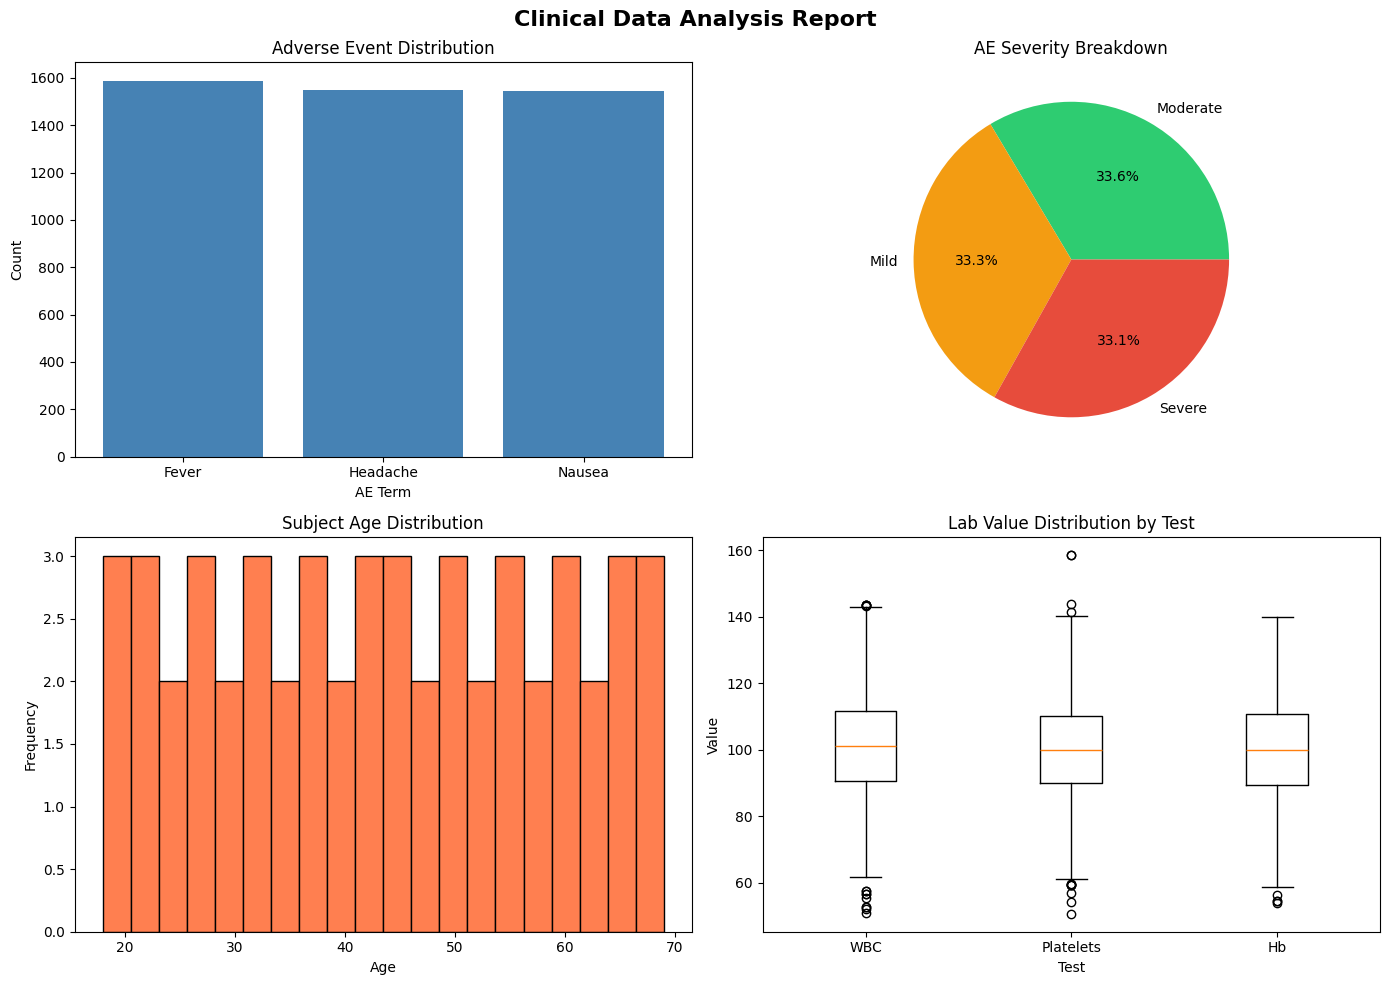

Report saved as clinical_report.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Clinical Data Analysis Report', fontsize=16, fontweight='bold')

# 1. AE Term Distribution
ae_counts = df['AE_TERM'].value_counts()
axes[0,0].bar(ae_counts.index, ae_counts.values, color='steelblue')
axes[0,0].set_title('Adverse Event Distribution')
axes[0,0].set_xlabel('AE Term')
axes[0,0].set_ylabel('Count')

# 2. Severity Breakdown
sev_counts = df['SEVERITY'].value_counts()
axes[0,1].pie(sev_counts.values, labels=sev_counts.index, autopct='%1.1f%%',
              colors=['#2ecc71','#f39c12','#e74c3c'])
axes[0,1].set_title('AE Severity Breakdown')

# 3. Age Distribution
axes[1,0].hist(df['AGE'].drop_duplicates(), bins=20, color='coral', edgecolor='black')
axes[1,0].set_title('Subject Age Distribution')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Frequency')

# 4. Lab Values by Test (Boxplot)
test_groups = [group['VALUE'].values for name, group in df.groupby('TEST')]
test_names = df['TEST'].unique().tolist()
axes[1,1].boxplot(test_groups, labels=test_names)
axes[1,1].set_title('Lab Value Distribution by Test')
axes[1,1].set_xlabel('Test')
axes[1,1].set_ylabel('Value')

plt.tight_layout()
plt.savefig('clinical_report.png', dpi=150)
plt.show()
print("Report saved as clinical_report.png")

**Export Summary to Excel**

In [8]:
with pd.ExcelWriter('SDTM_Domains.xlsx') as writer:
    DM.to_excel(writer, sheet_name='DM', index=False)
    AE.to_excel(writer, sheet_name='AE', index=False)
    LB.to_excel(writer, sheet_name='LB', index=False)

print("SDTM domains exported to SDTM_Domains.xlsx")

# Download the file
from google.colab import files
files.download('SDTM_Domains.xlsx')
files.download('clinical_report.png')

SDTM domains exported to SDTM_Domains.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>